# Libs and config

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    classification_report,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
pd.set_option("display.max_columns", None)

# Functions

In [54]:
def evaluate_classificator(y_true, y_pred, y_proba, model):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    F1_score = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    report = {
        "model": model,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "F1_score": F1_score,
        "Total_Postives": tp + fn,
        "Preds_Positives": tp + fp,
        "True_Positives": tp,
    }

    return pd.DataFrame([report])

# Data

In [4]:
df = pd.read_csv(
    "../data/df_cleaned.csv",
)

display(df.head())

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Student Loan,Not Specified,Home Equity Loan,Mortgage Loan,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Auto Loan,Payday Loan,Credit_Score_binomial
0,CUS_0x1000,202201,17,30625.94,2706.161667,6.0,27.0,2,62,1.63,10.0,1562.91,26.612093,10.166667,42.94109,244.750283,252.924793,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,1,0,1,0,0,0,0,0
1,CUS_0x1000,202202,17,30625.94,2706.161667,6.0,27.0,2,62,1.63,11.0,1562.91,29.439759,10.250000,42.94109,176.132567,311.542510,23.0,Lawyer,Bad,High_spent_Small_value_payments,Yes,0,0,1,0,1,0,0,0,0,1
2,CUS_0x1000,202203,17,30625.94,2706.161667,6.0,27.0,2,62,1.63,11.0,1562.91,38.285928,10.333333,42.94109,109.056519,368.618557,28.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,1,0,1,0,0,0,0,1
3,CUS_0x1000,202204,17,30625.94,2706.161667,6.0,27.0,2,64,1.63,11.0,1562.91,32.843081,10.416667,42.94109,87.909909,419.765167,25.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,1,0,1,0,0,0,0,1
4,CUS_0x1000,202205,17,30625.94,2706.161667,6.0,27.0,2,67,2.63,11.0,1562.91,32.330508,10.500000,42.94109,191.834767,305.840309,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,1,0,1,0,0,0,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   num_month                 100000 non-null  int64  
 2   Age                       100000 non-null  int64  
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Interest_Rate             100000 non-null  float64
 7   Num_of_Loan               100000 non-null  int64  
 8   Delay_from_due_date       100000 non-null  int64  
 9   Changed_Credit_Limit      100000 non-null  float64
 10  Num_Credit_Inquiries      100000 non-null  float64
 11  Outstanding_Debt          100000 non-null  float64
 12  Credit_Utilization_Ratio  100000 non-null  float64
 13  Credit_History_Age        100000 non-null  fl

# Prepare data

In [12]:
numerical_columns = df.select_dtypes(
    include=["float32", "float64", "int32", "int64", "bool"]
).columns.to_list()
numerical_columns.remove("num_month")
numerical_columns.remove("Credit_Score_binomial")

categorical_columns = df.select_dtypes(include=["object", "string"]).columns.to_list()

categorical_columns.remove("Customer_ID")
target = "Credit_Score_binomial"
final_features = categorical_columns + numerical_columns

In [35]:
X = df[final_features].copy()
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75000, 29)
(25000, 29)
(75000,)
(25000,)


In [ ]:
# OHencoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# scaler = StandardScaler()

# X_train_cat = OHencoder.fit_transform(X_train[categorical_columns])
# X_train_numeric = scaler.fit_transform(X_train[numerical_columns])
# encoded_names =OHencoder.get_feature_names_out(categorical_columns)
# X_train_cat = pd.DataFrame(
#     X_train_cat,
#     columns = encoded_names,
#     index = X_train.index
# )

# X_train_numeric = pd.DataFrame(
#     X_train_numeric,
#     columns = numerical_columns,
#     index = X_train.index
# )

# X_train_t = pd.concat([X_train_cat, X_train_numeric], axis =1)

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns),
    ],
    remainder="passthrough",
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Modelling

In [79]:
final_report = []

## 1. Logistic Regressor

In [80]:
lr_model = LogisticRegression(class_weight="balanced")

lr_model.fit(X_train_preprocessed, y_train)
y_pred_lr = lr_model.predict(X_test_preprocessed)
y_proba_lr = lr_model.predict_proba(X_test_preprocessed)[:, 1]

lr_report = evaluate_classificator(
    y_test, y_pred_lr, y_proba_lr, lr_model.__class__.__name__
)
final_report.append(lr_report)
lr_report

,model,roc_auc,pr_auc,precision,recall,F1_score,Total_Postives,Preds_Positives,True_Positives
0,LogisticRegression,0.811653,0.617408,0.596507,0.720927,0.652842,7249,8761,5226


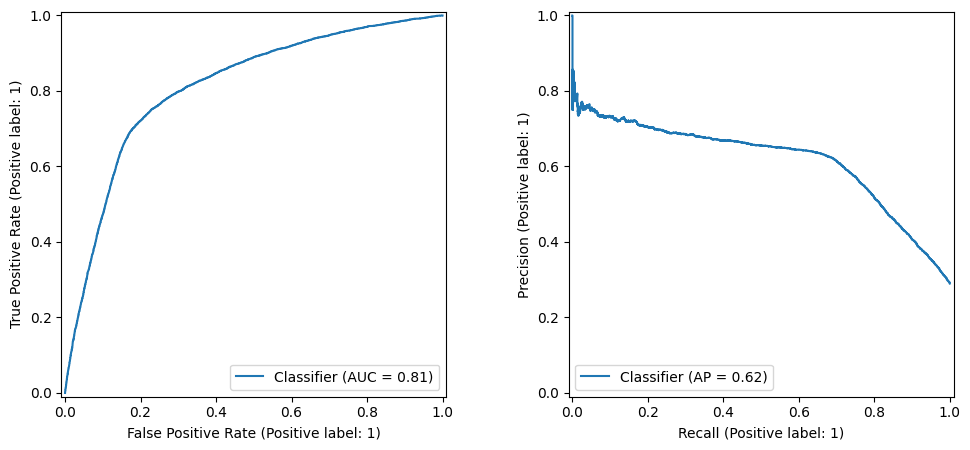

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1])
plt.show()

## 2. Logistic Regressor

In [82]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=5, random_state=42, n_jobs=1
)

rf_model.fit(X_train_preprocessed, y_train)
y_pred_rf = rf_model.predict(X_test_preprocessed)
y_proba_rf = rf_model.predict_proba(X_test_preprocessed)[:, 1]

rf_report = evaluate_classificator(
    y_test, y_pred_rf, y_proba_rf, rf_model.__class__.__name__
)
final_report.append(rf_report)
rf_report

,model,roc_auc,pr_auc,precision,recall,F1_score,Total_Postives,Preds_Positives,True_Positives
0,RandomForestClassifier,0.845824,0.691602,0.701191,0.641606,0.670076,7249,6633,4651


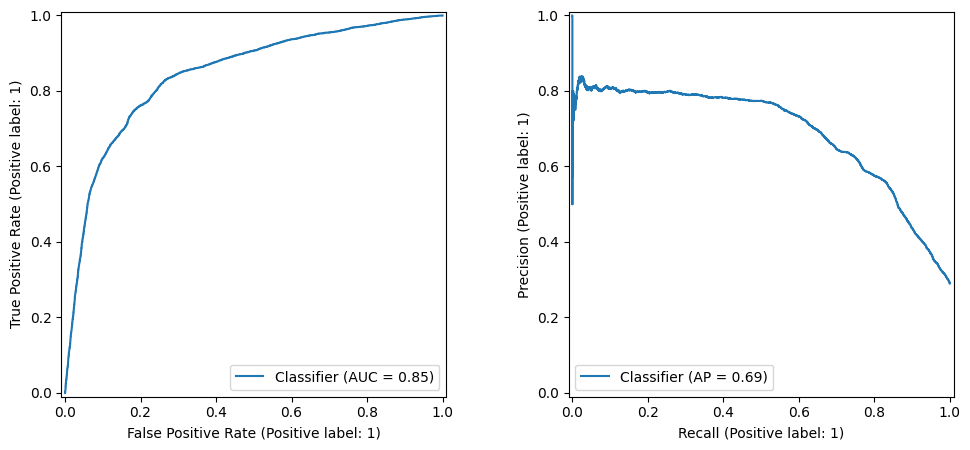

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
plt.show()

## 3. XGBOost

In [84]:
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=1
)

xgb_model.fit(X_train_preprocessed, y_train)
y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_proba_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

xgb_report = evaluate_classificator(
    y_test, y_pred_xgb, y_proba_xgb, xgb_model.__class__.__name__
)
final_report.append(xgb_report)
xgb_report

,model,roc_auc,pr_auc,precision,recall,F1_score,Total_Postives,Preds_Positives,True_Positives
0,XGBClassifier,0.899289,0.754874,0.761276,0.691544,0.724736,7249,6585,5013


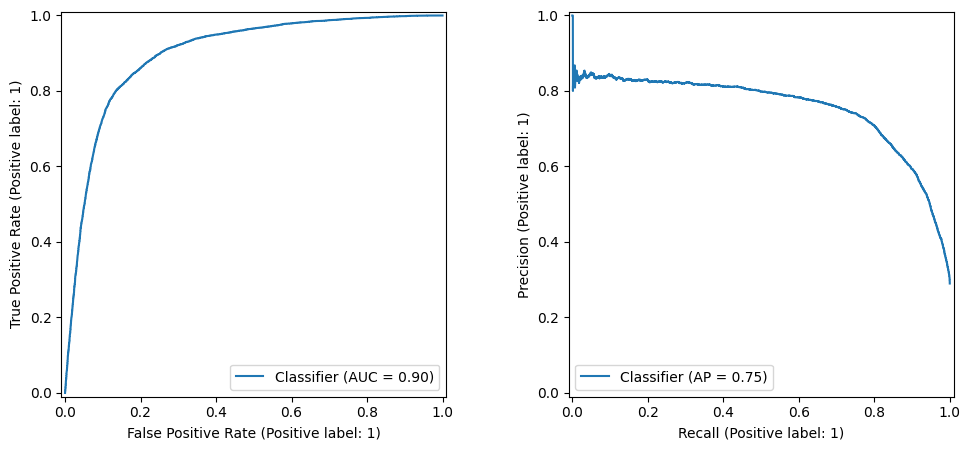

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, ax=axes[1])
plt.show()

# Conclusion

In [90]:
pd.concat(final_report).sort_values(by="pr_auc", ascending=False)

,model,roc_auc,pr_auc,precision,recall,F1_score,Total_Postives,Preds_Positives,True_Positives
0,XGBClassifier,0.899289,0.754874,0.761276,0.691544,0.724736,7249,6585,5013
0,RandomForestClassifier,0.845824,0.691602,0.701191,0.641606,0.670076,7249,6633,4651
0,LogisticRegression,0.811653,0.617408,0.596507,0.720927,0.652842,7249,8761,5226
